# Import dataset

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("job_salary_prediction_dataset[1].csv")
print(data.head() , "\n")
print("Shape of the Dataset: ",data.shape)

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069   

Shape of the Dataset:  (250000, 10)


# Check for Missing values

In [2]:
data.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [3]:
#list of columns

data.columns.tolist()

['job_title',
 'experience_years',
 'education_level',
 'skills_count',
 'industry',
 'company_size',
 'location',
 'remote_work',
 'certifications',
 'salary']

# Correlation of target with features

In [4]:
# correlation of target with numerical features

cor_matrix = data[["skills_count", "experience_years", "certifications","salary"]].corr()
print(cor_matrix["salary"].sort_values(ascending=False))

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [5]:
# correlation of target with job_title  

job_title_correlation = data.groupby('job_title')["salary"].mean().sort_values(ascending=False)
print(job_title_correlation)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64


In [6]:
# correlation of target with location column

city_correlation = data.groupby('location')["salary"].mean().sort_values(ascending=False)
print(city_correlation)

location
USA            181716.303919
Canada         167391.273396
UK             160075.143018
Germany        153376.211000
Remote         139442.525155
Sweden         139440.637291
Australia      139362.150804
Singapore      139340.696625
Netherlands    139294.813644
India           97690.402249
Name: salary, dtype: float64


In [7]:
# correlation of target with education level

edu_correlation = data.groupby('education_level')["salary"].mean().sort_values(ascending=False)
print(edu_correlation)

education_level
PhD            163976.005295
Master         153305.307833
Bachelor       142410.531291
Diploma        137158.574976
High School    131715.336243
Name: salary, dtype: float64


In [8]:
# correlation of target with company_size  

company_size_correlation = data.groupby('company_size')["salary"].mean().sort_values(ascending=False)
print(company_size_correlation)

company_size
Enterprise    169616.398957
Large         155711.112489
Medium        141537.535991
Small         134356.864298
Startup       127289.011974
Name: salary, dtype: float64


In [9]:
# correlation of target with industry 

industry_correlation = data.groupby('industry')["salary"].mean().sort_values(ascending=False)
print(industry_correlation)

industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64


#  Key Findings

In [10]:
# 1. Experience_year, job_title, location appears to be the strongest predictors of salary

# 2. Industry appears to have a weak influence on salary because average salaries are nearly identical across industries

# 3. Employees with higher education level tends to earn higher salaries

# 4. Salary of a person is impacted whether he works in startup or a big firm

# 5. Location tends to have a significant effect on salary since USA employees are earning higher salaries than other region employees

# Visual representation of correlations

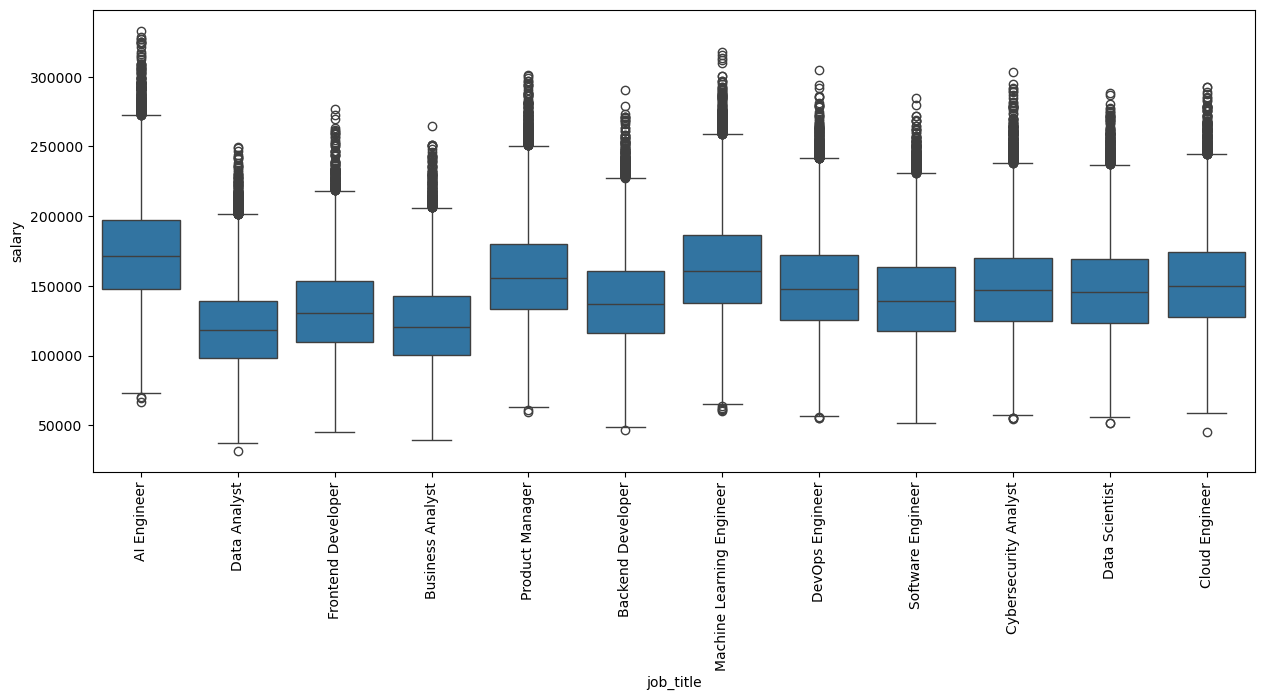

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(x="job_title", y="salary", data= data)

plt.xticks(rotation=90)
plt.show()

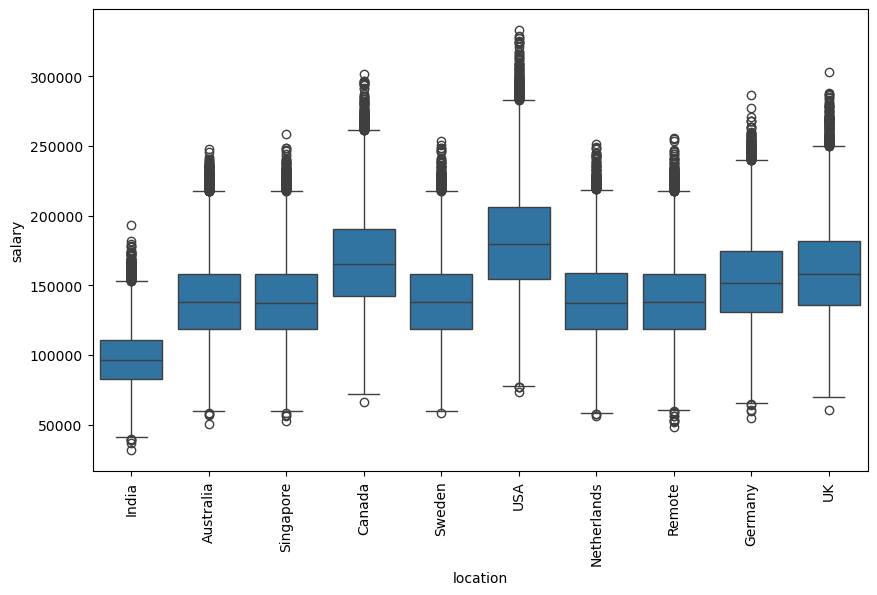

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x="location", y="salary", data=data)
plt.xticks(rotation=90)
plt.show()

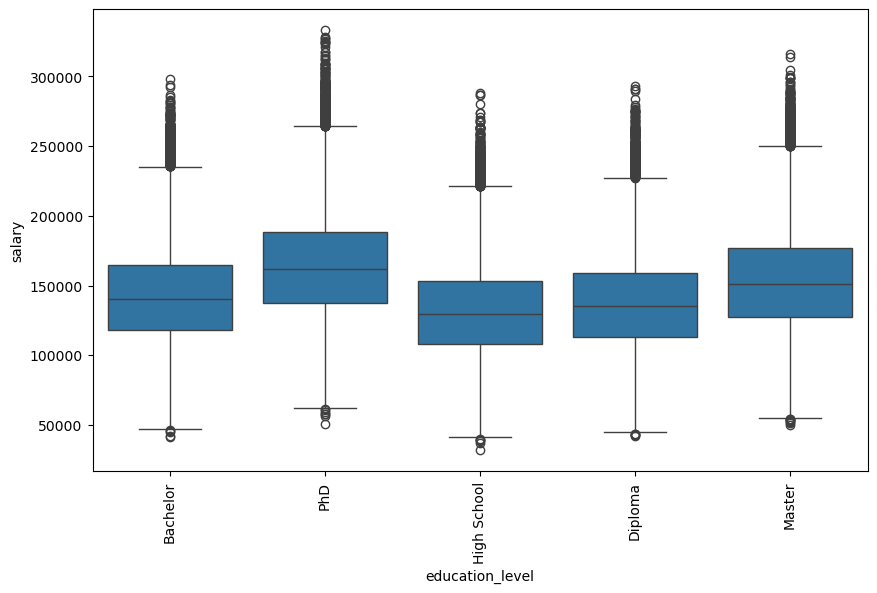

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x="education_level", y="salary", data=data)
plt.xticks(rotation=90)
plt.show()

# Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

data_copy = data.copy()

cat_cols = ["job_title", "industry", "location", "remote_work"]

# order for education 
edu_map = {"High School": 0,
           "Diploma": 1,
           "Bachelor": 2,
           "Master": 3,
           "PhD": 4}

# order for company size
company_map = {"Startup": 0,
               "Small": 1,
               "Medium": 2,
               "Large": 3,
               "Enterprise": 4}

# OneHotEncoding for categorial columns
data_copy = pd.get_dummies(data_copy, columns=cat_cols, drop_first=False)

# ordinal encoding on ordinal columns
data_copy["education_level"] = data_copy["education_level"].map(edu_map)
data_copy["company_size"] = data_copy["company_size"].map(company_map)

print(data_copy.head())

   experience_years  education_level  skills_count  company_size  \
0                10                2             2             2   
1                 5                2            17             1   
2                18                4             4             2   
3                19                4            13             2   
4                15                2             7             3   

   certifications  salary  job_title_AI Engineer  job_title_Backend Developer  \
0               2  109413                   True                        False   
1               0   93764                  False                        False   
2               1  148123                  False                        False   
3               0  189123                  False                        False   
4               0  165069                  False                        False   

   job_title_Business Analyst  job_title_Cloud Engineer  ...  location_India  \
0                       

# Correlation matrix

In [15]:
corr = data.corr(numeric_only=True)
print(corr["salary"].sort_values(ascending=False))

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


<Axes: >

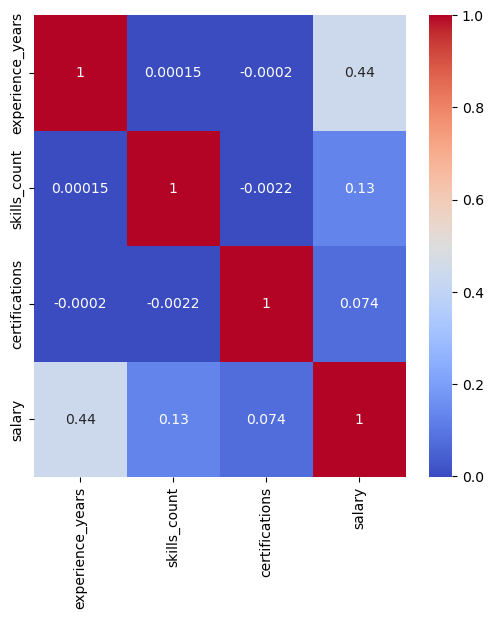

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Target Analysis

<Axes: xlabel='salary', ylabel='Count'>

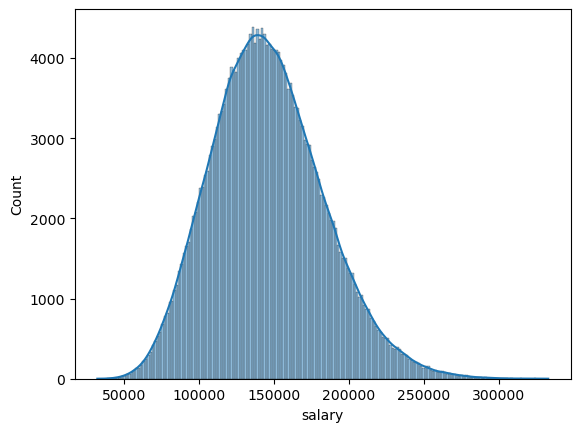

In [17]:
sns.histplot(data["salary"], kde=True)

In [18]:
data["salary"].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

#  Feature Engineering

In [19]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEngineering(BaseEstimator, TransformerMixin):
#     def fit(self, x, y=None):
    #     return self

    # def transform(self, x):
    #     x = x.copy()

    #     # education mapping
    #     edu_map = {"High School": 0,
    #        "Diploma": 1,
    #        "Bachelor": 2,
    #        "Master": 3,
    #        "PhD": 4}

    #     # Location mapping
    #     loc_map = {"USA": 9,
    #                "Canada": 8,
    #                "UK": 7,
    #                "Germany": 6,
    #                "Remote": 5,
    #                "Sweden": 4,
    #                "Australia": 3,
    #                "Singapore": 2,
    #                "Netherlands": 1,
    #                "India": 0}
        
    #     # company mapping
    #     company_map = {"Startup": 0,
    #            "Small": 1,
    #            "Medium": 2,
    #            "Large": 3,
    #            "Enterprise": 4}

    #     # total experience
    #     x["education_year"] = x["education_level"].map(edu_map)
    #     x["total_experience"] = (x["experience_years"] + x["education_year"])

    #     # company-size-location feature
    #     x["loc_level"] = x["location"].map(loc_map)
    #     x["comp"] = x["company_size"].map(company_map)

    #     x["comp_size_loc"] = (x["loc_level"] + x["comp"])

    #     # remove temporary columns
    #     x.drop(columns=["loc_level","comp","education_year"], axis=1,inplace=True)

    #     return x

# Encoding Pipeline

In [20]:
# unique education level present in dataset

edu_level = data["education_level"].unique().tolist()
print(edu_level)

['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']


In [21]:
#different column set for different encoding

cat_cols = ["job_title", "industry","location", "remote_work"]
ordinal_cols = ["education_level","company_size"]

 # education mapping
edu_map = ["High School","Diploma", "Bachelor","Master","PhD"]

# company mapping
company_map = ["Startup","Small","Medium","Large","Enterprise"]

# numerical columns
num_cols = ['experience_years', 'skills_count', 'certifications',
       'total_experience','comp_size_loc']

In [22]:
#  preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
                  ("ordinal", OrdinalEncoder(categories=[edu_map, company_map]), ordinal_cols),
                  ("scale", StandardScaler(), num_cols)])

preprocessor2 = ColumnTransformer(
    transformers=[("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
                 ("num", "passthrough", num_cols)])

# Split Dataset

In [23]:
from sklearn.model_selection import train_test_split

x = data.drop(["salary"], axis =1)
y = data["salary"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

# sc = StandardScaler()
# x_train[num_cols] = sc.fit_transform(x_train[num_cols])
# x_test[num_cols] = sc.transform(x_test[num_cols])

print(num_cols)

['experience_years', 'skills_count', 'certifications', 'total_experience', 'comp_size_loc']


# Linear Regression

In [24]:
# Model creation

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from feature_engineering import FeatureEngineering

pipeline_lr = Pipeline([("FeatureEngineering", (FeatureEngineering())),("Preprocessor", preprocessor), ("model", LinearRegression())])

# training model
pipeline_lr.fit(x_train, y_train)

,steps,"[('FeatureEngineering', ...), ('Preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
fe = FeatureEngineering()
temp = fe.transform(x_train.copy())
print(temp.columns.tolist())

['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'total_experience', 'comp_size_loc']


In [26]:
# prediction
pred_lr = pipeline_lr.predict(x_test)

# evaluation
from sklearn.metrics import r2_score, mean_absolute_error

print("R2_score: ", r2_score(y_test, pred_lr))
print("mean_absolute_error: ", mean_absolute_error(y_test, pred_lr))

R2_score:  0.9553766063497002
mean_absolute_error:  6059.226836628332


#  Cross validation for Linear Reg

In [27]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline_lr, x, y, cv= 5, scoring="r2")

print(scores)
print("Mean R2:", scores.mean())

[0.95571078 0.9555467  0.95530549 0.95549217 0.95504984]
Mean R2: 0.9554209966490168


# Random Forest Model

In [28]:
# model creation

from sklearn.ensemble import RandomForestRegressor

pipeline_rf = Pipeline([("FeatureEngineering", (FeatureEngineering())),
                        ("preprocessor", preprocessor2),
                        ("model", RandomForestRegressor(n_estimators=50, random_state=42))])

# training model
pipeline_rf.fit(x_train, y_train)

,steps,"[('FeatureEngineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
# prediction
pred_rf = pipeline_rf.predict(x_test)

# evaluation
from sklearn.metrics import r2_score, mean_absolute_error

print("R2_score: ", r2_score(y_test, pred_rf))
print("mean_absolute_error: ", mean_absolute_error(y_test, pred_rf))

R2_score:  0.9601378774338406
mean_absolute_error:  5900.186758585714


# Cross Validation for Random Forest Model

In [ ]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline_rf, x, y, cv= 5, scoring="r2")

print(scores)
print("Mean R2:", scores.mean())

# Features Importance

In [30]:
feature_names = pipeline_rf.named_steps["preprocessor"].get_feature_names_out()

importances = pipeline_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"Feature": feature_names,
                                      "Importance": importances})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                 Feature  Importance
8     num__comp_size_loc    0.419870
7  num__total_experience    0.264906
0         cat__job_title    0.161690
2          cat__location    0.070091
5      num__skills_count    0.028230
4  num__experience_years    0.026867
6    num__certifications    0.011881
1          cat__industry    0.009501
3       cat__remote_work    0.006963


In [33]:
sample = x_test.iloc[[0]]

print(sample)

actual_salary = y_test.iloc[0]
predicted_salary = pipeline_rf.predict(sample)[0]

print("Actual Salary:", actual_salary)
print("Predicted Salary:", predicted_salary)

         job_title  experience_years education_level  skills_count industry  \
38683  AI Engineer                11        Bachelor             7  Telecom   

      company_size location remote_work  certifications  
38683      Startup   Canada      Hybrid               3  
Actual Salary: 164009
Predicted Salary: 179758.46


In [34]:
import joblib

joblib.dump(pipeline_rf, "salary_prediction_pipeline.pkl")

['salary_prediction_pipeline.pkl']